# 03 — Feature Selection

**Dataset:** Global Coral Bleaching Database 1980–2020 (van Woesik & Kratochwill 2022)  
**Target variable:** `Bleaching_Category`

---

## Contents

1. Column inventory and categorisation
2. Drop of non-features
3. Drop of high-missingness columns
4. Multicollinearity analysis
5. Correlation with target variable
6. Feature set finalisation
7. Saving the dataset post-feature selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy.stats import spearmanr
from scipy.stats import kruskal

# Setting pandas to show all columns: the dataset has 60 columns and pandas truncates by default
pd.set_option('display.max_columns', None)

In [2]:
# Project colour palette: ocean themed 🌊
color_primary = 'teal'
color_secondary = 'coral'  
color_accent = 'turquoise'

## 1. Column inventory and categorisation

Exploring the columns to verify which can be dropped and which are to be retained for multicollinearity analysis and feature selection.

In [3]:
# Importing the post-EDA data
df = pd.read_csv('../data/processed/bleaching_eda.csv', low_memory=False)
print(df.shape)
df.head()

(41361, 60)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,State_Island_Province_Name,City_Town_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Date_Day,Date_Month,Date_Year,Depth_m,Substrate_Name,Percent_Cover,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Bleaching_Binary,Bleaching_Category,Bleaching_Severity_Ordinal
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,NaN,Tropical Atlantic,Cuba and Cayman Islands,Cuba,Havana,Havana,8519.23,Exposed,0.0287,49.90,15,9,2005,10.00,NaN,NaN,50.2,301.61,302.05,300.67,296.72,304.69,1.60,8.0,-0.46,1.0,0.0,-3.56,2.24,0.0,3.13,17.00,3.0,0.00,1.63,7.88,0.98,-0.80,1.60,-6.12,1.83,-2.17,0.00,1.09,5.0,0.0,0.00,0.74,7.25,0.18,2005-09-15,1,moderate,2.0
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,NaN,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,Society Islands,Moorea,1431.62,Exposed,0.0262,51.20,15,3,1991,14.00,NaN,NaN,50.7,262.15,303.30,300.73,297.58,305.01,1.12,2.0,1.29,1.0,0.0,-2.73,3.10,0.5,2.77,13.25,2.0,0.26,1.48,11.41,0.72,1.29,1.12,-4.42,3.00,-1.26,0.25,0.93,4.0,0.0,0.26,0.67,4.65,0.19,1991-03-15,1,moderate,2.0
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,British Virgin Islands,Peter Island,182.33,Exposed,0.0429,61.52,15,1,2006,7.00,NaN,NaN,50.9,298.79,299.18,300.32,297.12,304.14,1.22,8.0,0.04,1.0,0.0,-2.92,2.83,16.0,4.52,23.00,3.0,0.00,2.45,16.24,1.26,-2.64,1.22,-4.69,2.31,-1.49,7.00,1.31,7.0,0.0,0.00,1.04,11.66,0.26,2006-01-15,1,moderate,2.0
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,313.13,Exposed,0.0424,65.39,15,4,2006,9.02,NaN,NaN,50.9,300.16,299.61,300.38,297.25,304.07,1.19,3.0,-0.07,1.0,0.0,-2.77,2.47,22.0,4.75,24.00,3.0,0.00,2.37,16.73,1.07,-2.27,1.19,-4.63,2.19,-1.49,3.00,0.94,4.0,0.0,0.00,0.75,5.64,0.20,2006-04-15,1,moderate,2.0
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,792.00,Exposed,0.0424,65.39,15,4,2006,12.50,NaN,NaN,50.9,300.15,299.70,300.38,296.63,303.76,1.18,3.0,0.00,1.0,0.0,-2.84,2.30,16.0,4.16,20.00,3.0,0.00,2.24,13.86,1.16,-2.19,1.18,-5.25,1.87,-1.50,3.00,1.33,5.0,0.0,0.00,0.92,6.89,0.25,2006-04-15,1,moderate,2.0


## 2. Drop of non-features

In [4]:
# Dropping the identifier columns
cols_identifiers = [
    'Site_ID', 'Sample_ID', 'Reef_ID',
    'City_Town_Name', 'State_Island_Province_Name',
    'Country_Name']

df = df.drop(columns=cols_identifiers)
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 54


### Drop of identifier columns

The following columns are pure identifiers or geographic labels too granular to carry 
modelling signal. Latitude and longitude already identify each observation precisely.

- `Site_ID`, `Sample_ID`, `Reef_ID`: arbitrary numeric identifiers
- `City_Town_Name`, `State_Island_Province_Name`: too granular, redundant with coordinates
- `Country_Name`: redundant with higher-level geographic aggregations (`Ocean_Name`, `Realm_Name`)

In [5]:
cols_target_derived = [
    'Percent_Bleaching',
    'Bleaching_Binary', 
    'Bleaching_Severity_Ordinal']

df = df.drop(columns=cols_target_derived)
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 51


### Drop of target-derived columns

`Percent_Bleaching` is the continuous source variable from which `Bleaching_Category` 
was derived. `Bleaching_Binary` and `Bleaching_Severity_Ordinal` are alternative 
encodings of the same target. Keeping any of these would cause data leakage.

### Date components

Investigating all Date columns prior to dropping any of them.

In [6]:
df['Date_Day'].value_counts()

Date_Day
15    7662
20    1270
22    1269
19    1256
21    1249
9     1248
10    1247
23    1245
13    1231
27    1227
24    1216
14    1206
17    1199
25    1194
12    1187
8     1181
7     1170
16    1161
29    1145
26    1143
11    1120
18    1117
6     1098
28    1094
30    1073
5     1010
1      962
4      887
2      855
3      853
31     586
Name: count, dtype: int64

### Drop of date components

`Date_Day` is too variable to carry ecological signal: it reflects survey scheduling, 
not bleaching dynamics. `Date` is the full datetime string, redundant with `Date_Year` 
and `Date_Month` which are already present as numeric columns.

The sanity check performed during data cleaning already confirmed that `Date` and `Date_Year` and `Date_Month` are consistent and do not carry different information.

In [7]:
cols_date = ['Date_Day', 'Date']

df = df.drop(columns=cols_date)
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 49


In [8]:
df.columns.tolist()

['Data_Source',
 'Latitude_Degrees',
 'Longitude_Degrees',
 'Ocean_Name',
 'Realm_Name',
 'Ecoregion_Name',
 'Distance_to_Shore',
 'Exposure',
 'Turbidity',
 'Cyclone_Frequency',
 'Date_Month',
 'Date_Year',
 'Depth_m',
 'Substrate_Name',
 'Percent_Cover',
 'ClimSST',
 'Temperature_Kelvin',
 'Temperature_Mean',
 'Temperature_Minimum',
 'Temperature_Maximum',
 'Temperature_Kelvin_Standard_Deviation',
 'Windspeed',
 'SSTA',
 'SSTA_Standard_Deviation',
 'SSTA_Mean',
 'SSTA_Minimum',
 'SSTA_Maximum',
 'SSTA_Frequency',
 'SSTA_Frequency_Standard_Deviation',
 'SSTA_FrequencyMax',
 'SSTA_FrequencyMean',
 'SSTA_DHW',
 'SSTA_DHW_Standard_Deviation',
 'SSTA_DHWMax',
 'SSTA_DHWMean',
 'TSA',
 'TSA_Standard_Deviation',
 'TSA_Minimum',
 'TSA_Maximum',
 'TSA_Mean',
 'TSA_Frequency',
 'TSA_Frequency_Standard_Deviation',
 'TSA_FrequencyMax',
 'TSA_FrequencyMean',
 'TSA_DHW',
 'TSA_DHW_Standard_Deviation',
 'TSA_DHWMax',
 'TSA_DHWMean',
 'Bleaching_Category']

### Further inspection of `Percent_Cover` and `Cyclone_Frequency`

Before proceeding with multicollinearity analysis, two columns require closer inspection: 
`Percent_Cover` and `Cyclone_Frequency`. Their ecological meaning and data quality need 
to be assessed before deciding whether to retain them as features.

In [9]:
# Investigating the 'Percent_Cover' column
print(df['Percent_Cover'].describe().T)
print(df['Percent_Cover'].isna().sum())

count    28906.000000
mean        19.418280
std         20.850784
min          0.000000
25%          0.620000
50%         12.500000
75%         33.120000
max        100.000000
Name: Percent_Cover, dtype: float64
12455


In [10]:
# Investigating the 'Cyclone_Frequency' column
print(df['Cyclone_Frequency'].describe().T)
print(df['Cyclone_Frequency'].dtype)
print(df['Cyclone_Frequency'].isna().sum())

count    41361.000000
mean        52.159650
std          7.589593
min         18.310000
25%         47.940000
50%         50.920000
75%         55.730000
max        105.800000
Name: Cyclone_Frequency, dtype: float64
float64
0


`Percent_Cover` indicates the coralline coverage of the site. The descriptive statistics 
suggest a highly right-skewed distribution: the standard deviation is higher than the mean, 
indicating that most sites have low coral coverage while few have high coverage. 
The feature may carry ecological significance, but the high missingness (~30%) will be 
evaluated at a later stage of the feature selection.

`Cyclone_Frequency` has no missing values and an approximately normal distribution. 
This feature may be linked to thermal anomalies and will be further explored during 
the multicollinearity analysis.

## 3. Drop of high-missingness columns

In [11]:
# Investigating the percentage missingness of data in all remaining columns
missing_count = df.isnull().mean()
missing_pct = missing_count * 100
missing_sorted = missing_pct.sort_values(ascending=False)
missing_only = missing_sorted[missing_sorted > 0]
print(missing_only.round(2))

Substrate_Name                           30.63
Percent_Cover                            30.11
Bleaching_Category                       16.55
Depth_m                                   4.35
SSTA_Minimum                              0.43
SSTA                                      0.36
SSTA_Frequency                            0.36
Temperature_Kelvin                        0.36
TSA_Frequency                             0.36
SSTA_DHW                                  0.36
TSA                                       0.36
TSA_DHW                                   0.36
Temperature_Kelvin_Standard_Deviation     0.32
SSTA_Maximum                              0.32
SSTA_Standard_Deviation                   0.32
SSTA_Mean                                 0.32
SSTA_Frequency_Standard_Deviation         0.32
TSA_Mean                                  0.32
SSTA_DHW_Standard_Deviation               0.32
SSTA_FrequencyMax                         0.32
SSTA_FrequencyMean                        0.32
TSA_Standard_

In [12]:
print(f"Bleaching_Category NaN count: {df['Bleaching_Category'].isna().sum()}")
print(f"Total rows: {len(df)}")
print(f"Rows with valid target: {df['Bleaching_Category'].notna().sum()}")

Bleaching_Category NaN count: 6846
Total rows: 41361
Rows with valid target: 34515


In [13]:
# Dropping rows with no target variable
df = df.dropna(subset=['Bleaching_Category'])
print(f"Rows remaining: {len(df)}")

Rows remaining: 34515


`Bleaching_Category` had 6,846 missing values (16.55% of 41,361 rows).


These are original missing values from the raw dataset, not introduced during cleaning, 
as verified in Notebook 01. These rows have valid environmental features but no target 
value, and have been dropped.

The remaining 34,515 rows have a valid target and will form the modelling dataset.

In [14]:
# Dropping rows with NaN in feature columns (less than 1% of data)
cols_to_clean = ['SSTA', 'TSA_Frequency', 'TSA_DHW', 'TSA', 
                 'Temperature_Kelvin', 'SSTA_DHW', 'TSA_Mean',
                 'Temperature_Mean', 'TSA_Maximum', 'TSA_DHWMax',
                 'TSA_DHWMean', 'Temperature_Maximum', 'Windspeed',
                 'ClimSST', 'Turbidity', 'Ecoregion_Name', 'Distance_to_Shore']

df = df.dropna(subset=cols_to_clean)
print(f"Rows remaining: {len(df)}")

Rows remaining: 34388


In [15]:
# Checking NaNs in the 'Depth_m' column
print(df['Depth_m'].isna().sum())
print(f"Percentage: {df['Depth_m'].isna().mean()*100:.2f}%")

1677
Percentage: 4.88%


In [16]:
print(df['Depth_m'].describe().T)
print(df['Depth_m'].value_counts().sort_index().head(20))

count    32711.000000
mean         7.057654
std          4.235902
min          0.000000
25%          4.000000
50%          6.000000
75%         10.000000
max         50.300000
Name: Depth_m, dtype: float64
Depth_m
0.00     16
0.10     13
0.20      5
0.30     19
0.40     15
0.50     71
0.52      1
0.60     38
0.65      2
0.70     48
0.75      1
0.80     55
0.90     48
1.00    860
1.10     35
1.15      1
1.20    129
1.25      2
1.30    148
1.35      2
Name: count, dtype: int64


In [17]:
# Further inspecting the 'Depth_m' column to check whether it's influenced by class imbalance
print(df.groupby('Depth_m')['Bleaching_Category'].value_counts(normalize=True).unstack().describe())

Bleaching_Category        mild    moderate        none      severe
count               287.000000  296.000000  381.000000  227.000000
mean                  0.251926    0.275270    0.664847    0.237492
std                   0.236028    0.284715    0.255614    0.295581
min                   0.009804    0.006757    0.083333    0.007752
25%                   0.117647    0.068607    0.474576    0.040441
50%                   0.181818    0.153194    0.678571    0.104167
75%                   0.285714    0.361607    0.894737    0.333333
max                   1.000000    1.000000    1.000000    1.000000


In [18]:
depth_bins = pd.cut(df['Depth_m'], bins=[0, 5, 10, 20, 90])
print(df.groupby(depth_bins)['Bleaching_Category'].value_counts(normalize=True).unstack())

Bleaching_Category      mild  moderate      none    severe
Depth_m                                                   
(0, 5]              0.058615  0.042174  0.866770  0.032441
(5, 10]             0.071605  0.054885  0.837970  0.035540
(10, 20]            0.139004  0.093508  0.698256  0.069232
(20, 90]            0.098291  0.205128  0.440171  0.256410


In [19]:
# Checking the number of observation per bin
depth_bins = pd.cut(df['Depth_m'], bins=[0, 5, 10, 20, 90])
print(df.groupby(depth_bins)['Bleaching_Category'].count())

Depth_m
(0, 5]      13563
(5, 10]     13337
(10, 20]     5561
(20, 90]      234
Name: Bleaching_Category, dtype: int64


In [20]:
# Dropping rows with missing Depth_m values
df = df.dropna(subset=['Depth_m'])
print(f"Rows remaining: {len(df)}")

Rows remaining: 32711


### `Depth_m`

Analysis by depth bin shows that the proportion of severe bleaching appears to increase 
with depth. However, this pattern should be interpreted with caution: the deepest bin 
(20–90m) contains only 234 observations (< 1% of the dataset), making the apparent 
26% severe bleaching rate statistically unreliable and likely a sampling artefact.

The feature is nonetheless retained: depth modulates thermal stress exposure and carries 
ecological meaning. The shallower bins (0–20m), which represent 99% of observations, 
show a more reliable and ecologically consistent pattern.

Median imputation is not appropriate: depth is ecologically meaningful and imputing a 
central value would misrepresent the thermal environment of deep-water sites. The 1,677 
rows with missing `Depth_m` values (4.9%) have been dropped.

In [21]:
# Checking for correlation between 'Percent_Cover' and our target variable
severity_map = {'none': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
temp_ordinal = df['Bleaching_Category'].map(severity_map)

valid = df[['Percent_Cover']].copy()
valid['target'] = temp_ordinal
valid = valid.dropna()

corr, pval = spearmanr(valid['Percent_Cover'], valid['target'])
print(f"Spearman r: {corr:.3f}, p-value: {pval:.4f}, n: {len(valid)}")

Spearman r: 0.042, p-value: 0.0000, n: 22561


### Drop of `Percent_Cover`

The Spearman correlation between `Percent_Cover` and `Bleaching_Category` is r = 0.042,
negligible. The p-value is 0.0000, but this is an artefact of the large sample size 
(n = 22,561): with tens of thousands of observations, even trivial correlations become 
statistically significant. The effect size is what matters here, and it is negligible.

Given the high missingness (30.11%) and the lack of predictive signal, imputing missing 
values would introduce noise rather than information. The column is therefore dropped.

In [22]:
# Dropping 'Percent_Cover' column
df = df.drop(columns=['Percent_Cover'])
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 48


## 4. Multicollinearity analysis

Before finalising the feature set, we examine correlations among the remaining 48 columns
to identify redundant variables, particularly among the temperature and thermal stress variables (SSTA, TSA, DHW and their derivatives), which are likely to be highly collinear.

In [23]:
df.columns.tolist()

['Data_Source',
 'Latitude_Degrees',
 'Longitude_Degrees',
 'Ocean_Name',
 'Realm_Name',
 'Ecoregion_Name',
 'Distance_to_Shore',
 'Exposure',
 'Turbidity',
 'Cyclone_Frequency',
 'Date_Month',
 'Date_Year',
 'Depth_m',
 'Substrate_Name',
 'ClimSST',
 'Temperature_Kelvin',
 'Temperature_Mean',
 'Temperature_Minimum',
 'Temperature_Maximum',
 'Temperature_Kelvin_Standard_Deviation',
 'Windspeed',
 'SSTA',
 'SSTA_Standard_Deviation',
 'SSTA_Mean',
 'SSTA_Minimum',
 'SSTA_Maximum',
 'SSTA_Frequency',
 'SSTA_Frequency_Standard_Deviation',
 'SSTA_FrequencyMax',
 'SSTA_FrequencyMean',
 'SSTA_DHW',
 'SSTA_DHW_Standard_Deviation',
 'SSTA_DHWMax',
 'SSTA_DHWMean',
 'TSA',
 'TSA_Standard_Deviation',
 'TSA_Minimum',
 'TSA_Maximum',
 'TSA_Mean',
 'TSA_Frequency',
 'TSA_Frequency_Standard_Deviation',
 'TSA_FrequencyMax',
 'TSA_FrequencyMean',
 'TSA_DHW',
 'TSA_DHW_Standard_Deviation',
 'TSA_DHWMax',
 'TSA_DHWMean',
 'Bleaching_Category']

In [24]:
thermal_cols = [
    'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum',
    'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation', 'ClimSST',
    'SSTA', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Standard_Deviation',
    'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean',
    'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean',
    'TSA', 'TSA_Mean', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Standard_Deviation',
    'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean',
    'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean'
]

print(len(thermal_cols))
print([col for col in thermal_cols if col not in df.columns])

32
[]


In [25]:
# Separating the thermal columns in 3 lists: temperature, TSA and SSTA
temp_cols = ['Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum',
    'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation', 'ClimSST']

SSTA_cols = ['SSTA', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Standard_Deviation',
    'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean',
    'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean']

TSA_cols = ['TSA', 'TSA_Mean', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Standard_Deviation',
    'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean',
    'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean']

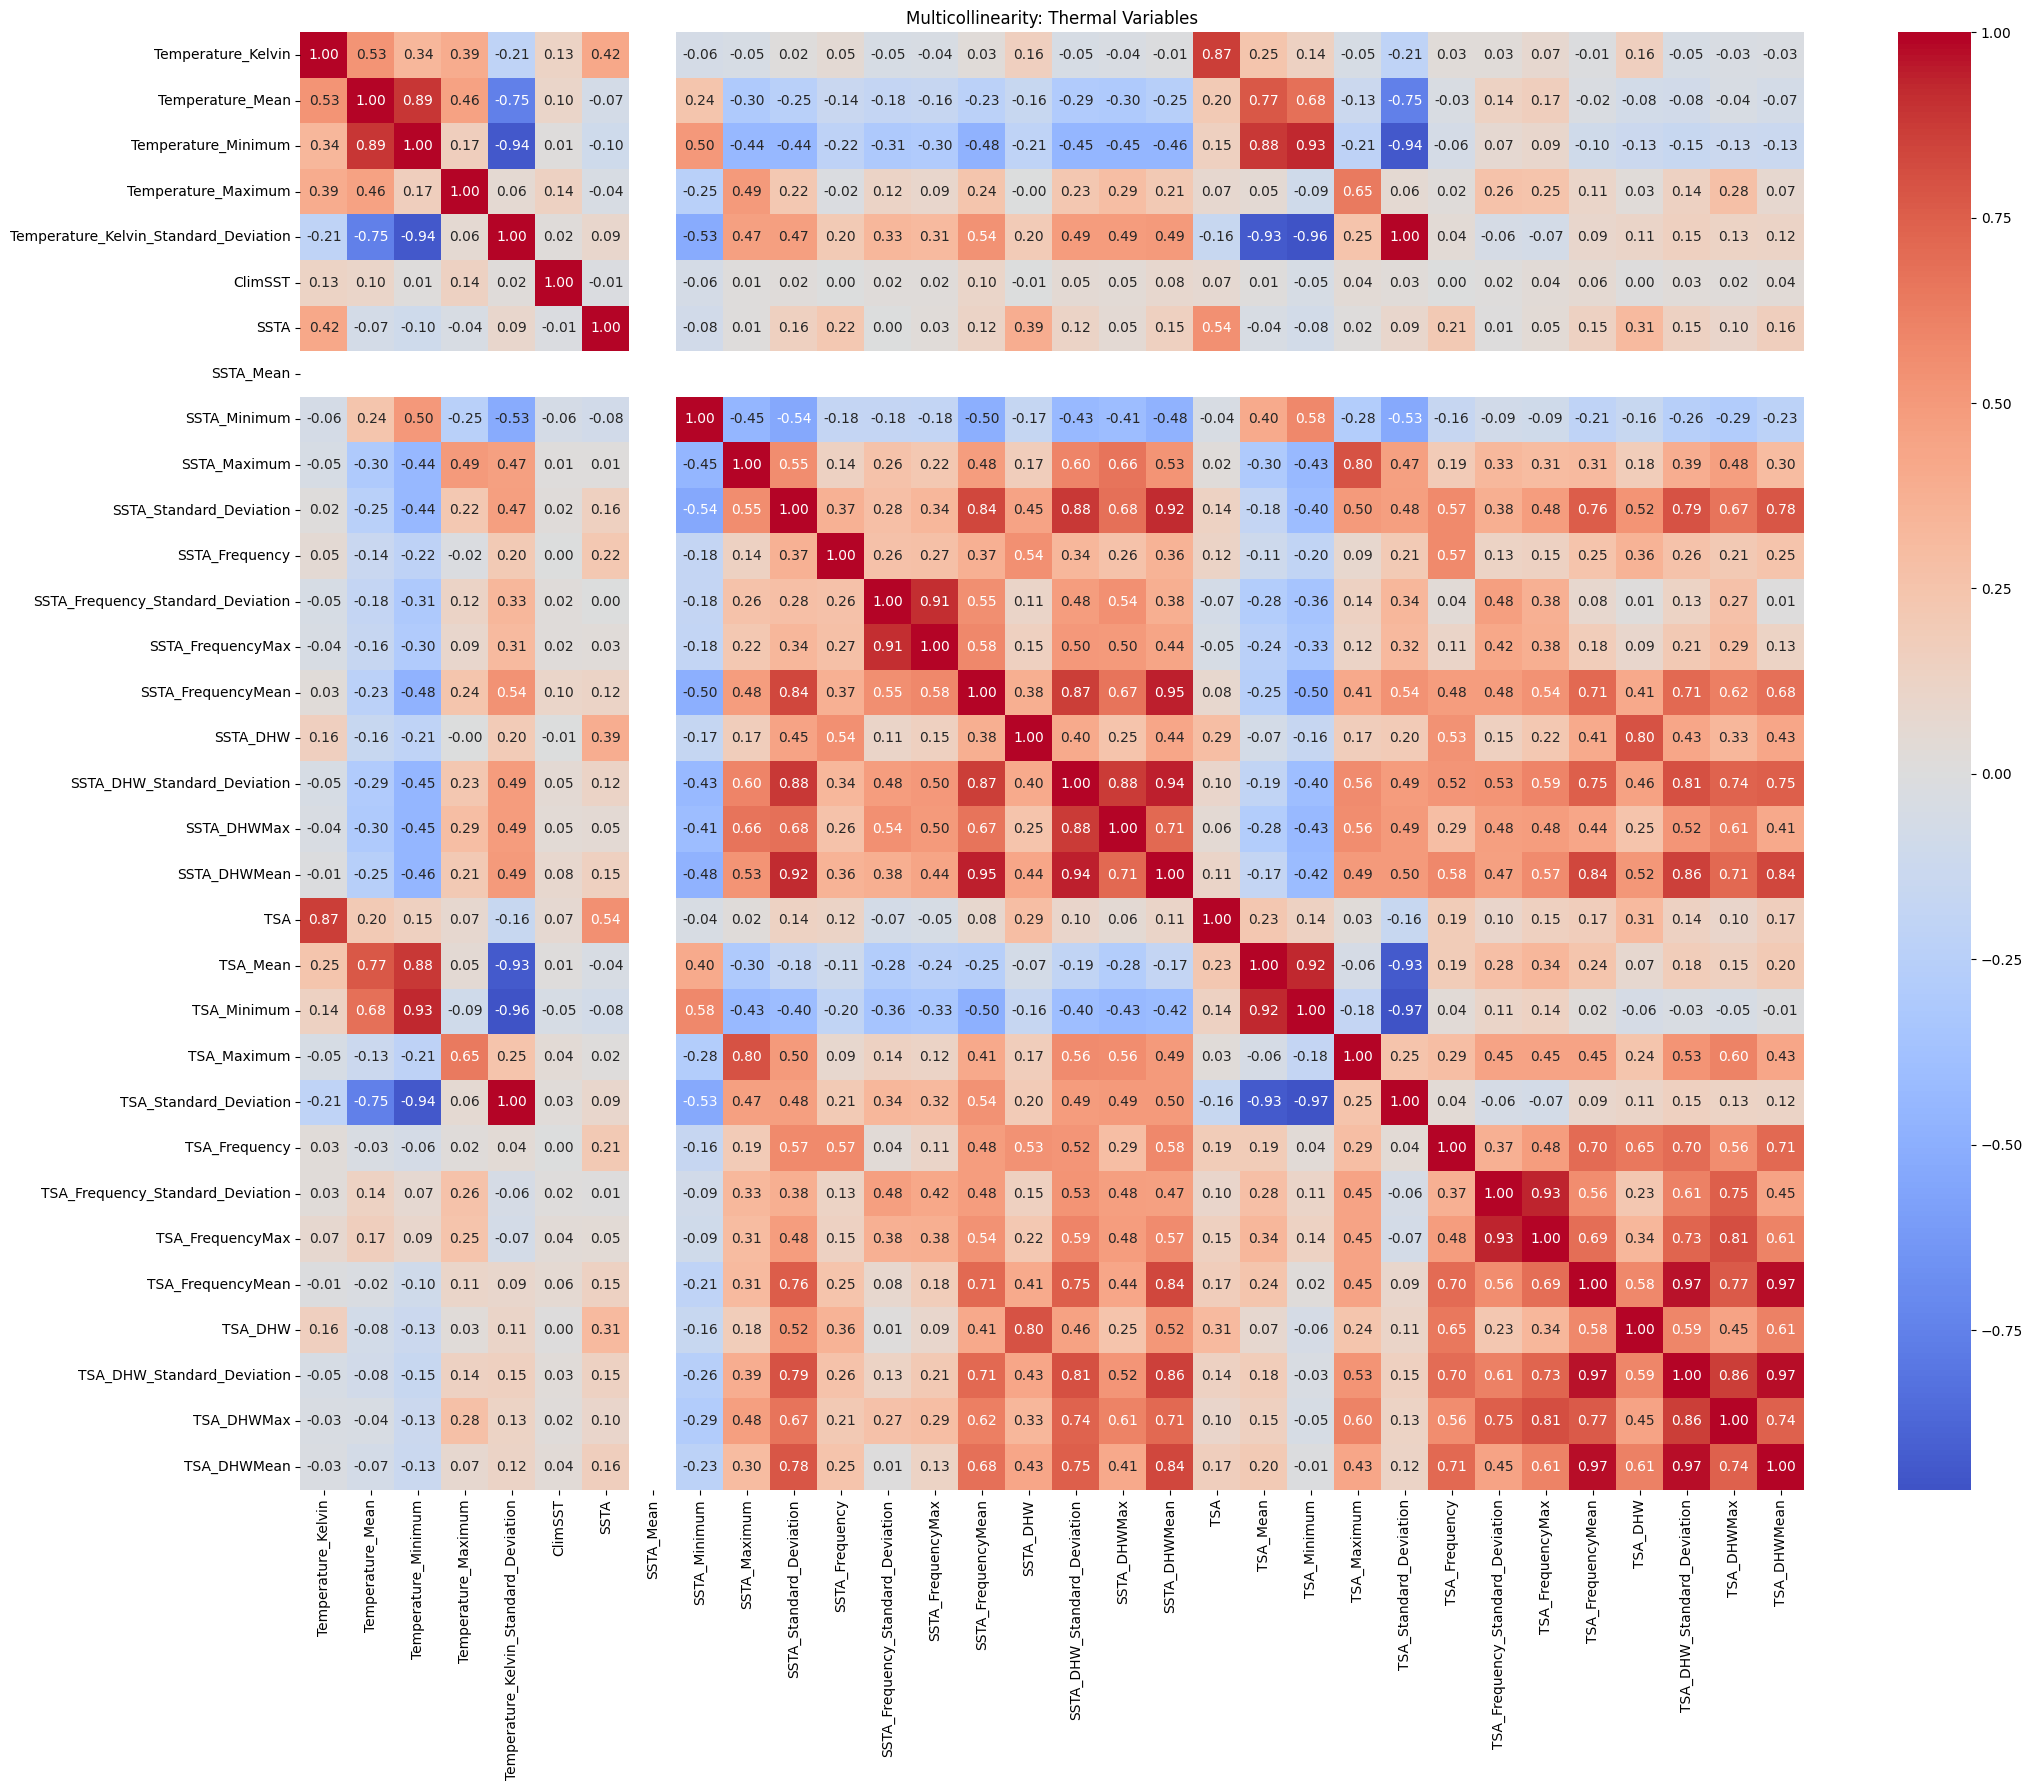

In [26]:
# Building the correlation matrix for all thermal features
corr_matrix = df[thermal_cols].corr()

plt.figure(figsize=(22, 18))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Multicollinearity: Thermal Variables')
plt.tight_layout()
plt.show()

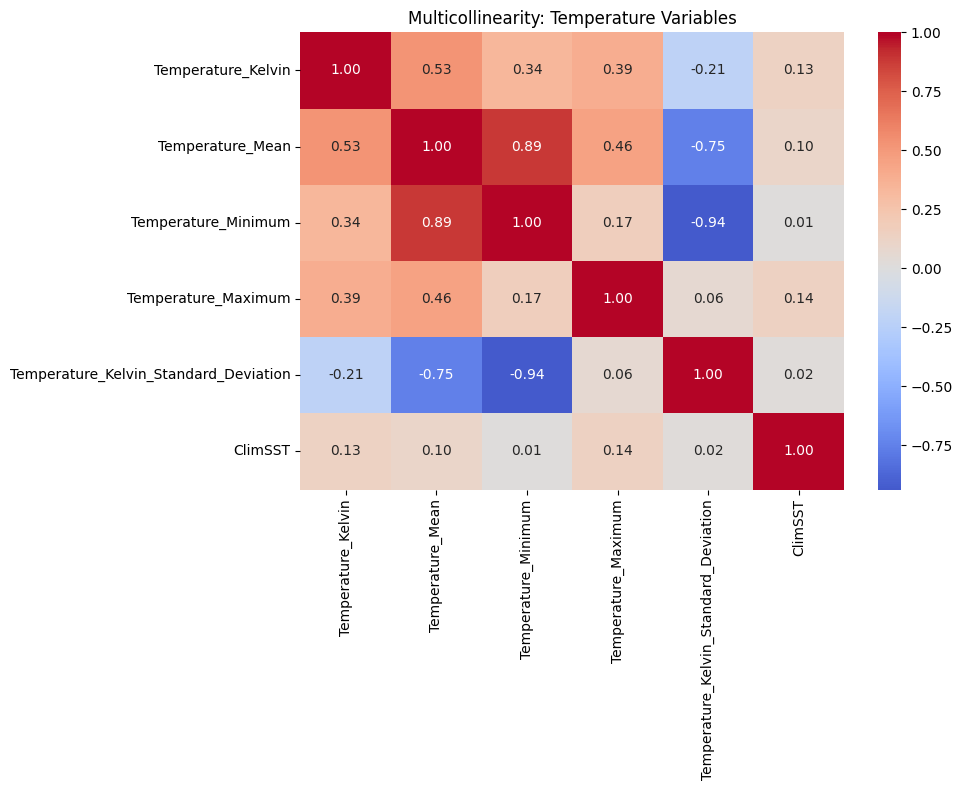

In [27]:
# Building the correlation matrix for temperature features for better readability
corr_matrix = df[temp_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Multicollinearity: Temperature Variables')
plt.tight_layout()
plt.show()

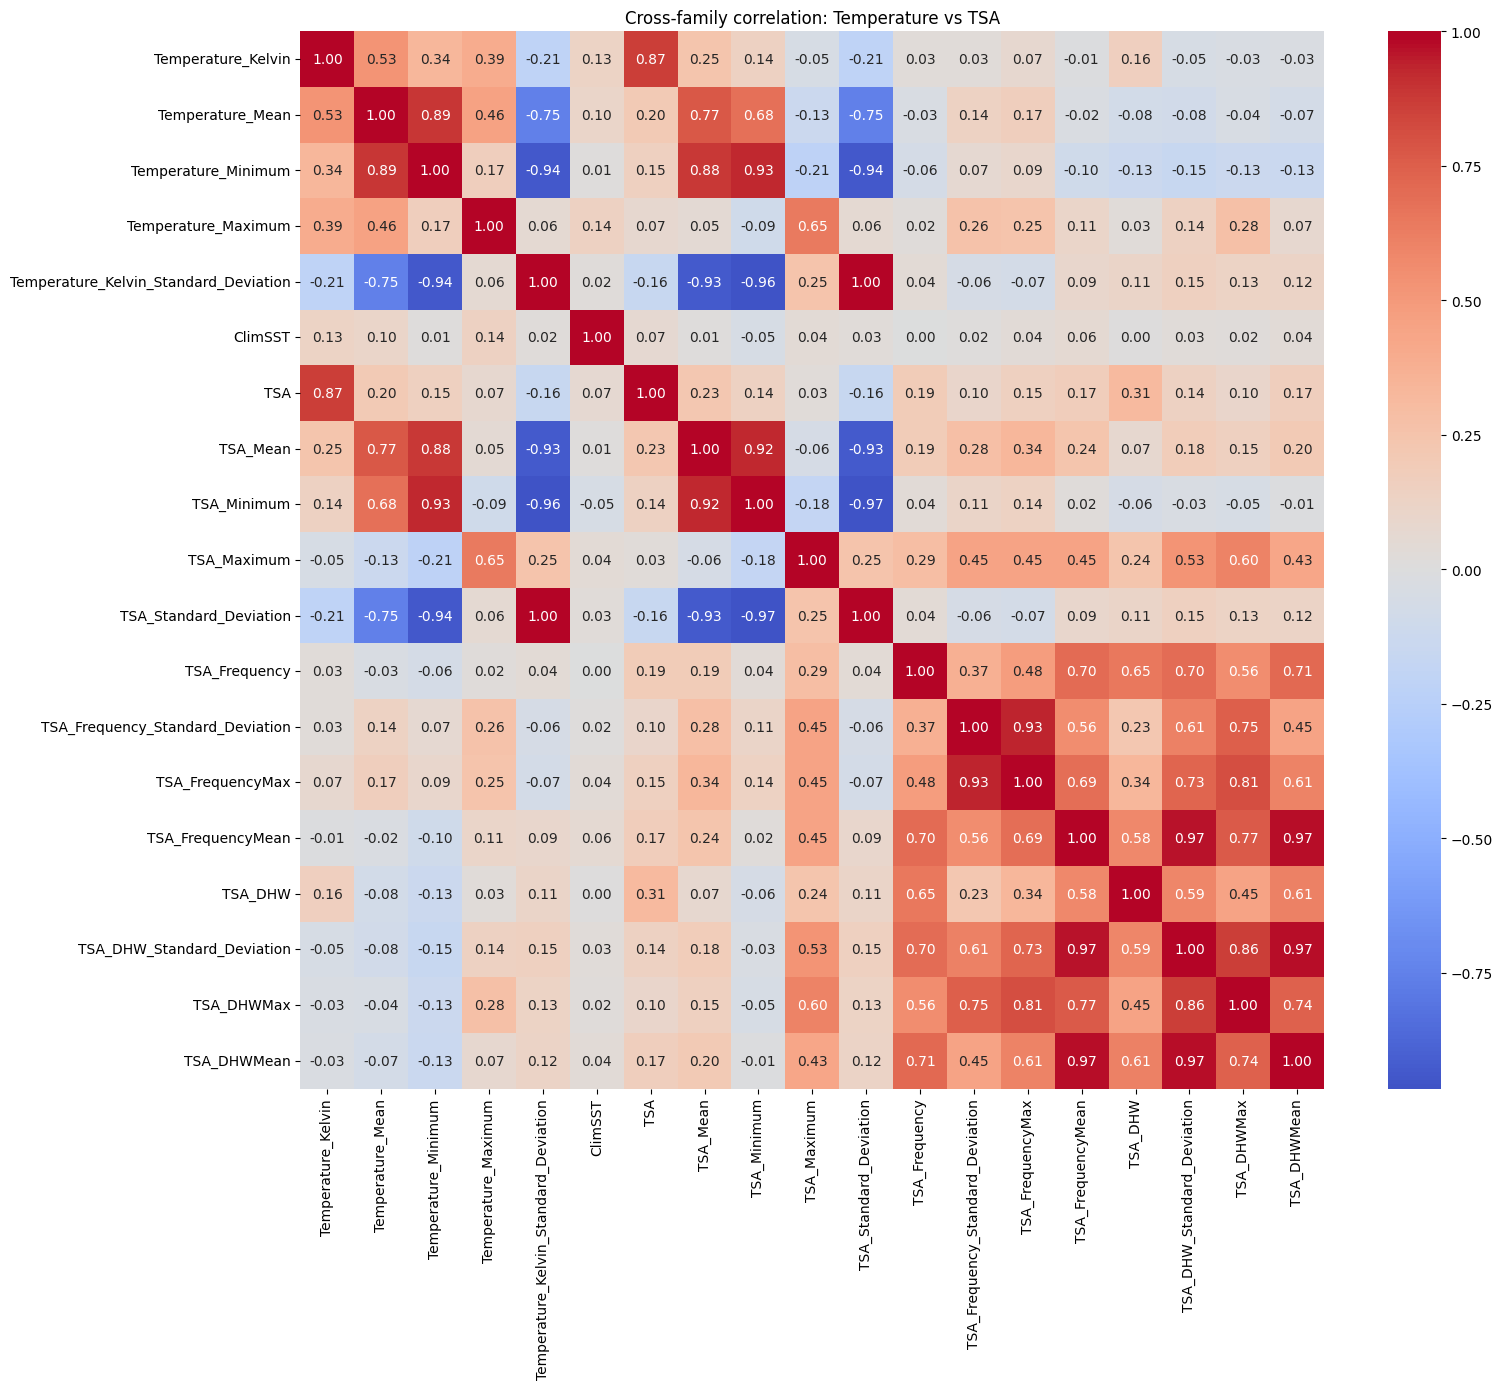

In [28]:
# Investigating the correlation between Temperature and TSA features
corr_temp_tsa = df[temp_cols + TSA_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_temp_tsa, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Cross-family correlation: Temperature vs TSA')
plt.tight_layout()
plt.show()

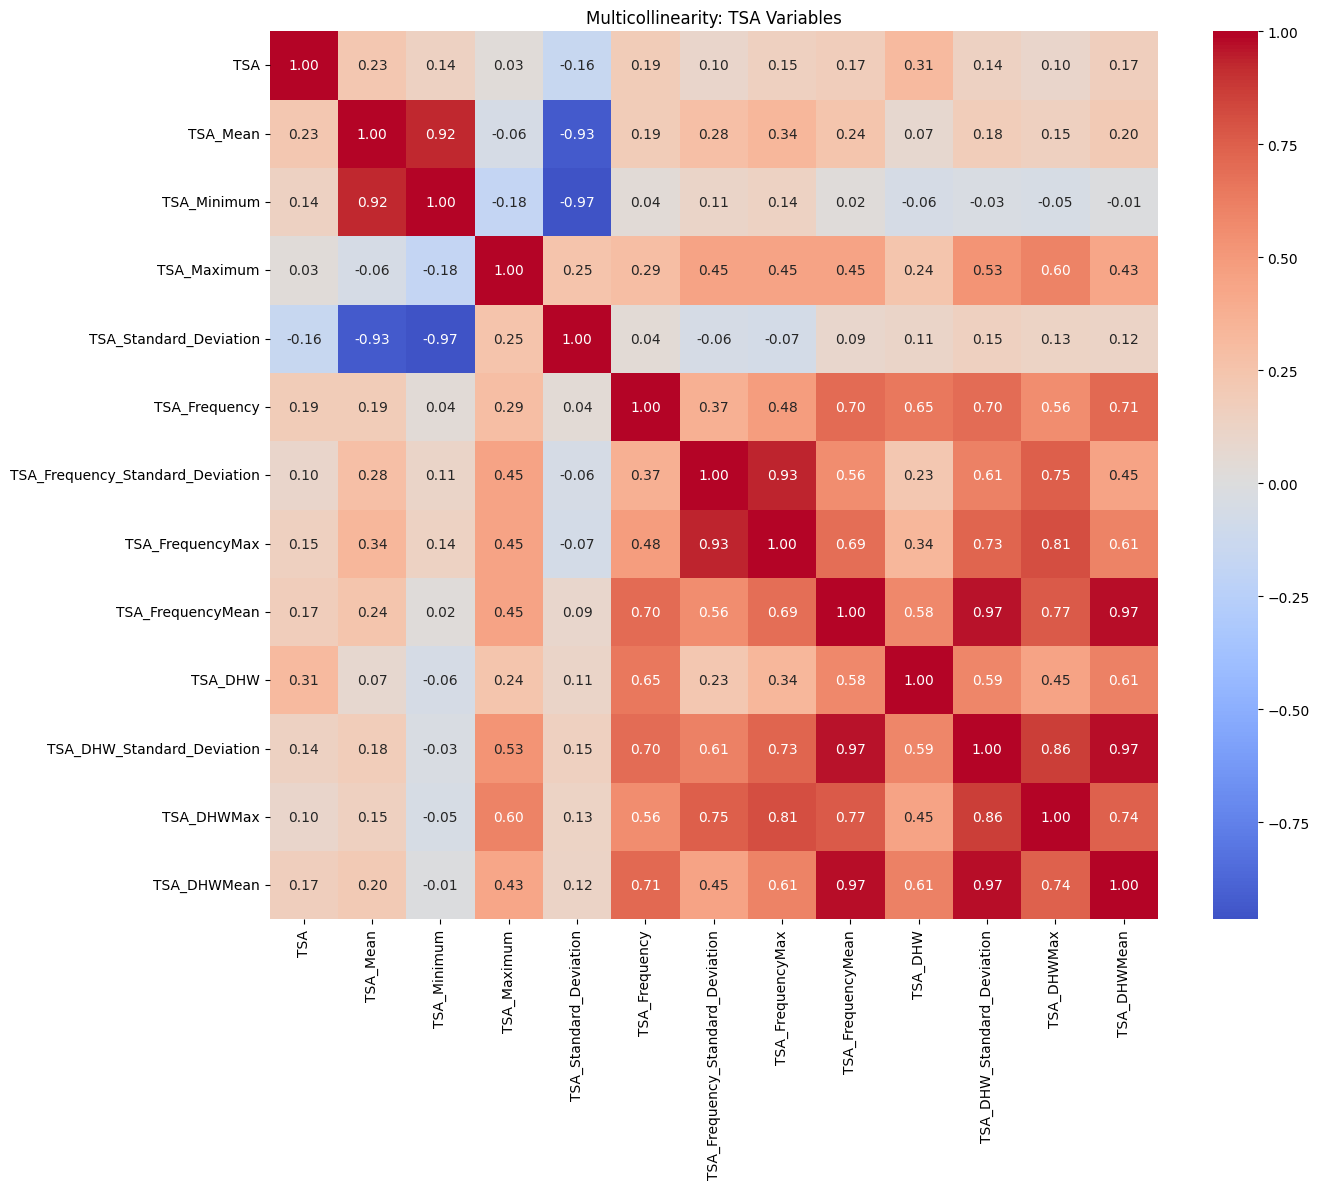

In [29]:
# Investigating the correlation within TSA features
corr_tsa = df[TSA_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_tsa, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Multicollinearity: TSA Variables')
plt.tight_layout()
plt.show()

In [30]:
# Checking Spearman correlation of TSA features with target variable
severity_map = {'none': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
temp_ordinal = df['Bleaching_Category'].map(severity_map)

for col in TSA_cols:
    valid = df[[col]].copy()
    valid['target'] = temp_ordinal
    valid = valid.dropna()
    corr, pval = spearmanr(valid[col], valid['target'])
    print(f"{col}: r={corr:.3f}, n={len(valid)}")

TSA: r=0.137, n=32711
TSA_Mean: r=-0.112, n=32711
TSA_Minimum: r=-0.042, n=32711
TSA_Maximum: r=-0.081, n=32711
TSA_Standard_Deviation: r=0.053, n=32711
TSA_Frequency: r=0.151, n=32711
TSA_Frequency_Standard_Deviation: r=-0.221, n=32711
TSA_FrequencyMax: r=-0.198, n=32711
TSA_FrequencyMean: r=-0.219, n=32711
TSA_DHW: r=0.271, n=32711
TSA_DHW_Standard_Deviation: r=-0.190, n=32711
TSA_DHWMax: r=-0.135, n=32711
TSA_DHWMean: r=-0.207, n=32711


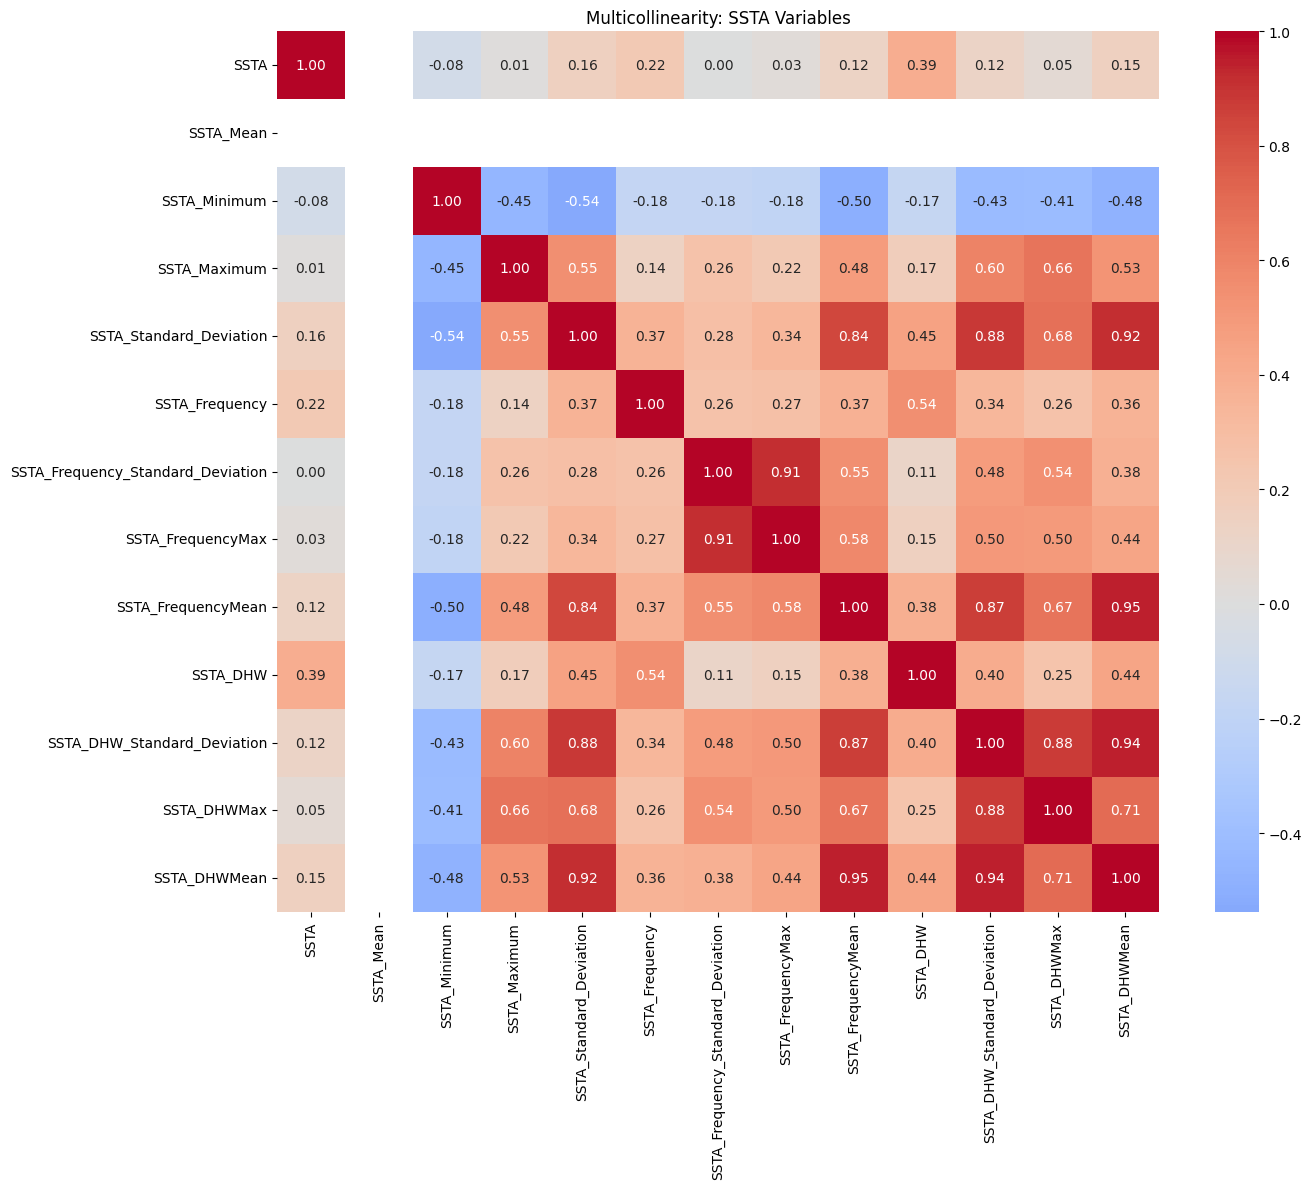

In [31]:
# Investigating the correlation within SSTA features
corr_ssta = df[SSTA_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_ssta, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Multicollinearity: SSTA Variables')
plt.tight_layout()
plt.show()

In [32]:
# SSTA_Mean is constant: value = 0.0. Zero variance, zero information
print(df['SSTA_Mean'].value_counts())

SSTA_Mean
0.0    32711
Name: count, dtype: int64


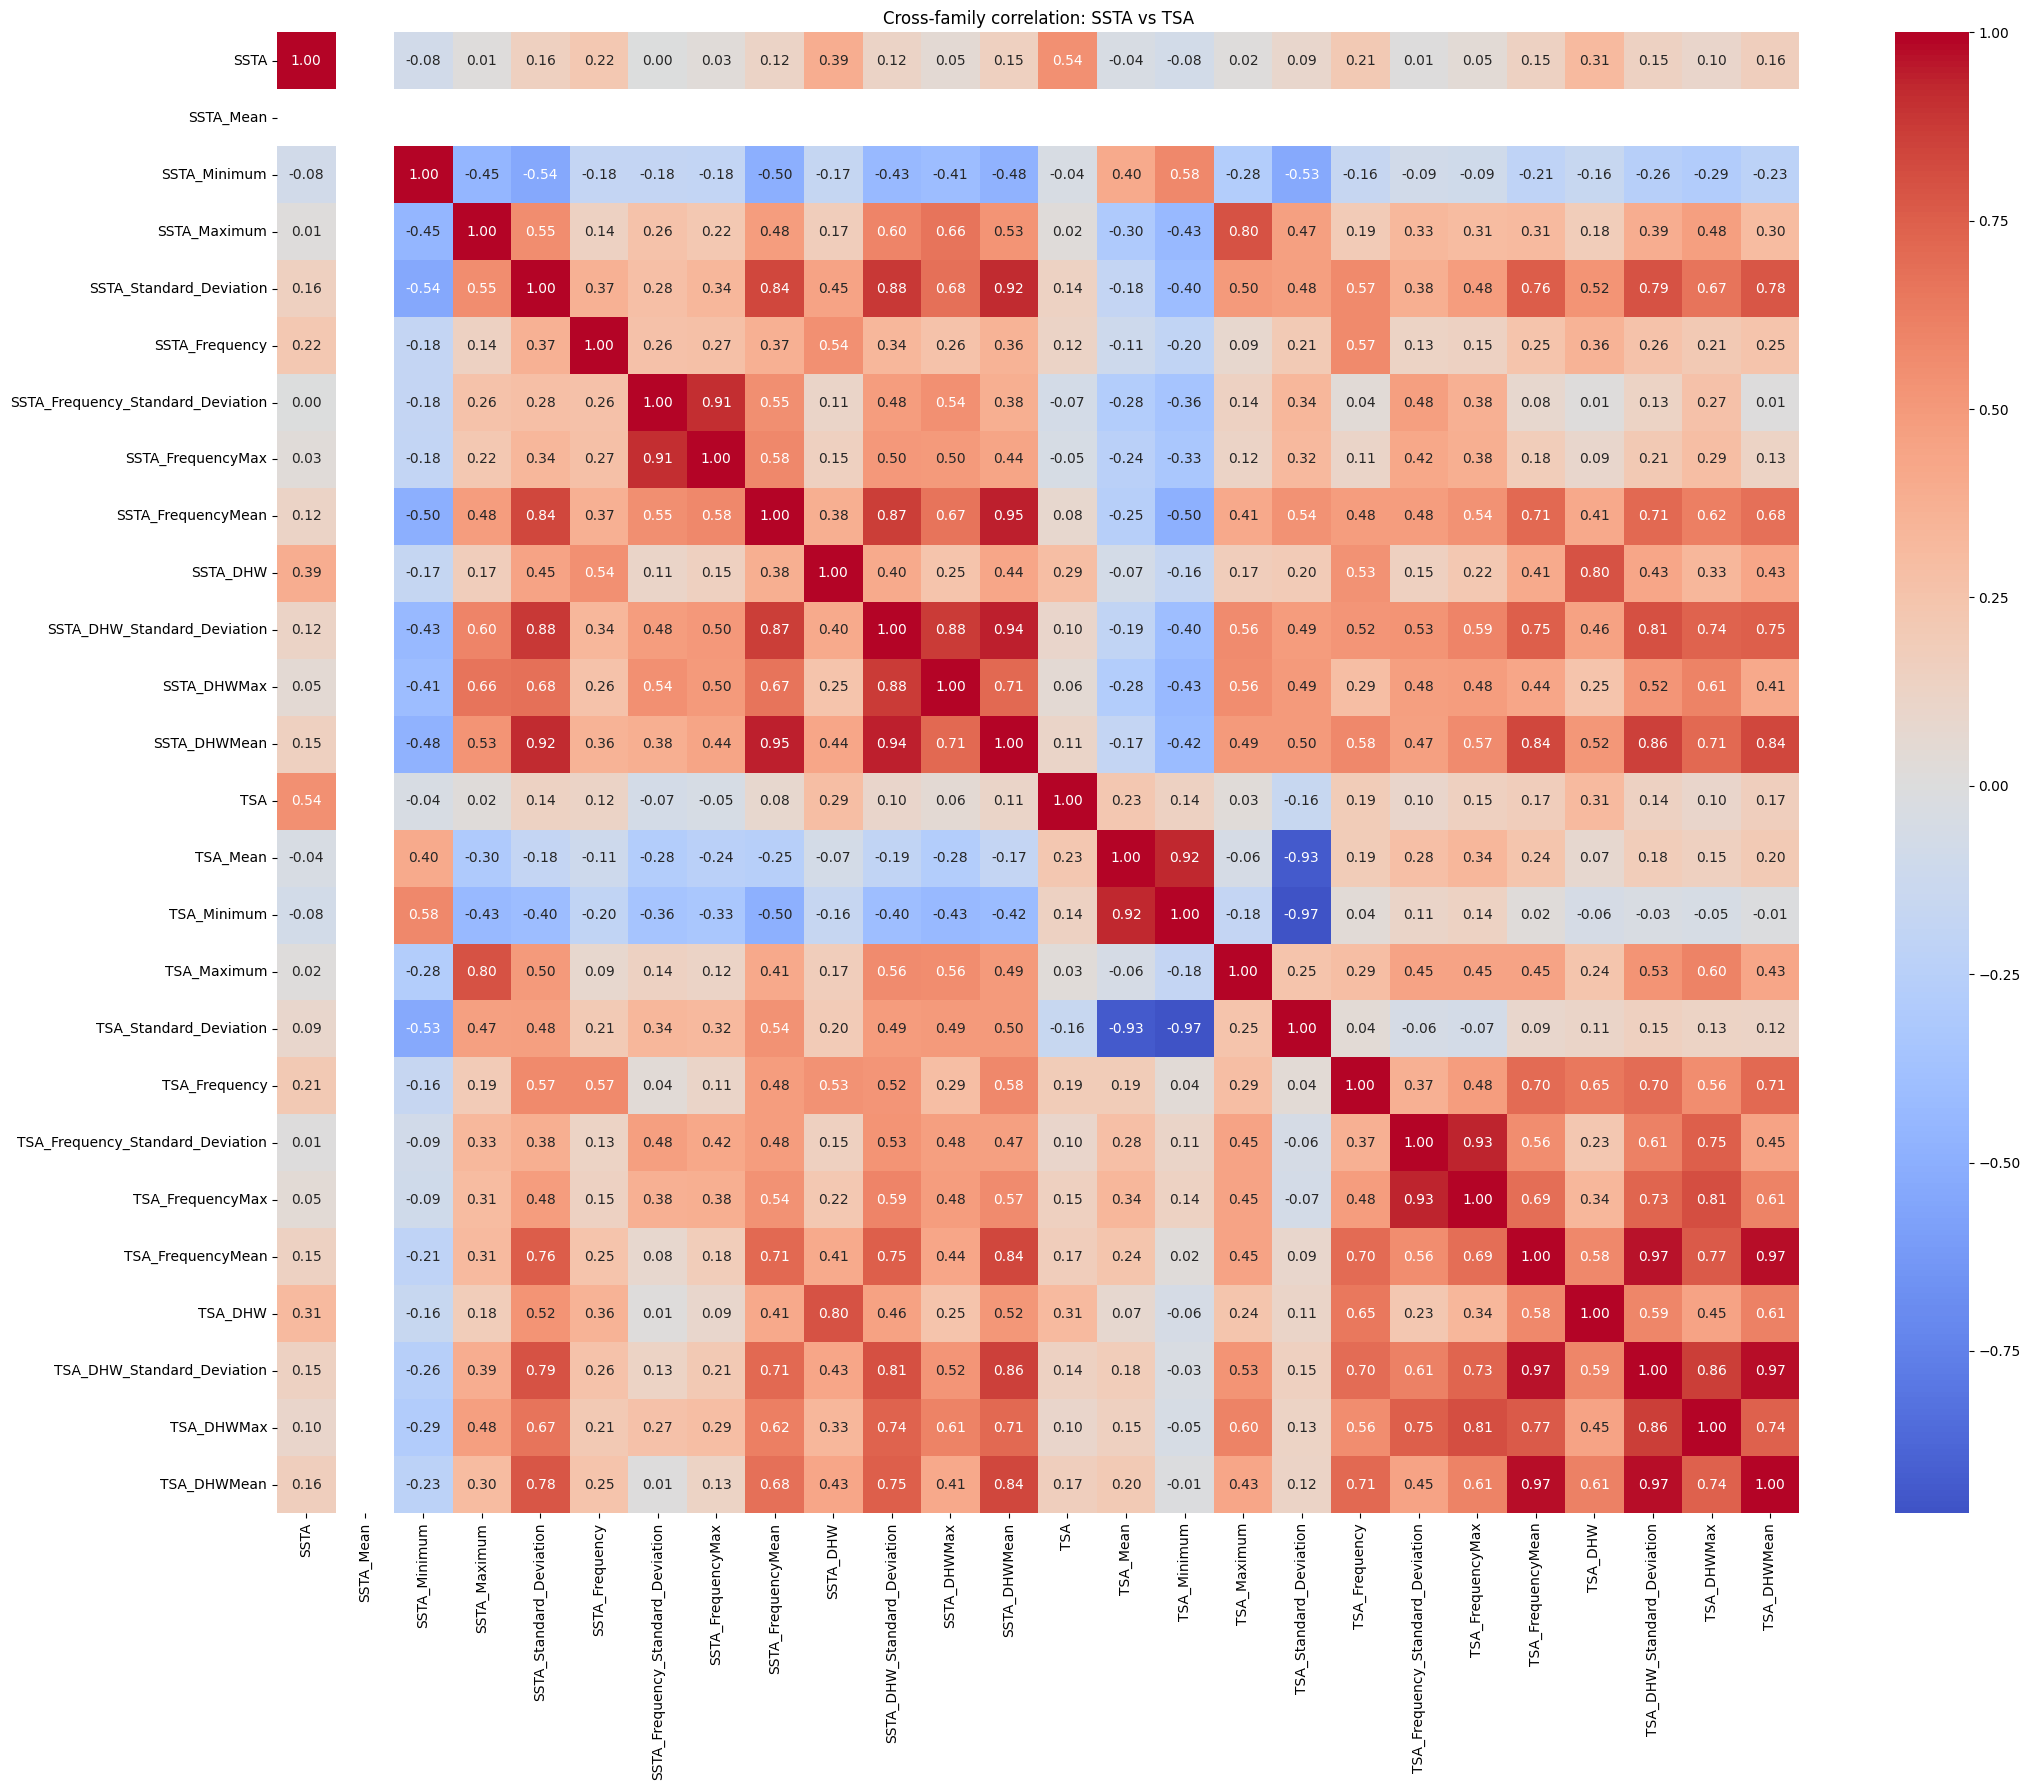

In [33]:
# Investigating the cross-family correlation between SSTA and TSA features
corr_ssta_tsa = df[SSTA_cols + TSA_cols].corr()

plt.figure(figsize=(22, 18))
sns.heatmap(corr_ssta_tsa, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Cross-family correlation: SSTA vs TSA')
plt.tight_layout()
plt.show()

In [34]:
# Verifying Spearman correlation of SSTA_DHW with target variable
valid = df[['SSTA_DHW']].copy()
valid['target'] = df['Bleaching_Category'].map({'none': 0, 'mild': 1, 'moderate': 2, 'severe': 3})
valid = valid.dropna()
corr, pval = spearmanr(valid['SSTA_DHW'], valid['target'])
print(f"SSTA_DHW: r={corr:.3f}, n={len(valid)}")

SSTA_DHW: r=0.194, n=32711


### Temperature Features

Following the analysis of the correlation matrix, `Temperature_Kelvin`, `Temperature_Maximum` and `Temperature_Mean` show moderate correlation with each other and are retained as features.

`ClimSST` is retained on ecological grounds as the historical baseline SST for each site; it shows negligible collinearity with all other features (r < 0.13).

`Temperature_Minimum` will be dropped: it is highly redundant with both `Temperature_Mean` (r=0.89) and `TSA_Standard_Deviation` (r=-0.93). `Temperature_Kelvin_Standard_Deviation` will be dropped: it is identical to `TSA_Standard_Deviation` (r=1.00) and highly redundant with `Temperature_Mean` (r=-0.74).

The cross-family analysis shows that Temperature and TSA features follow the same internal logic: temperatures, means and maximums correlate with each other. In particular `Temperature_Kelvin` and `TSA` show high correlation (r=0.85). However, they represent the absolute temperature at the time of observation and how much that temperature exceeds the historical monthly maximum respectively, and are therefore conceptually different. Both will be retained.

In [35]:
# Dropping 'Temperature_Minimum' and 'Temperature_Kelvin_Standard_Deviation' columns
df = df.drop(columns=['Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation'])
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 46


### SSTA Features

The SSTA family has been analysed both internally and in cross-family correlation with TSA.

`SSTA` (Sea Surface Temperature Anomaly) measures the difference between current SST and 
the climatological mean. It correlates moderately with `TSA` (r=0.55) but uses a different 
baseline and is therefore retained as a complementary feature.

`SSTA_DHW` (Degree Heating Weeks based on SSTA) is retained as it captures accumulated 
thermal stress using the SSTA baseline, complementary to `TSA_DHW`. It also shows the 
highest correlation with the target variable within the SSTA family (r=0.194, n=32,711).

All remaining SSTA features mirror their TSA counterparts (e.g. `SSTA_FrequencyMean` 
mirrors `TSA_FrequencyMean`, `SSTA_DHWMean` mirrors `TSA_DHWMean`), introducing 
redundancy without adding conceptually distinct information. They will be dropped.

In [36]:
# Dropping all SSTA columns except 'SSTA' and 'SSTA_DHW'
SSTA_to_drop = []
for col in df.columns:
    if col.startswith('SSTA') and col not in ['SSTA', 'SSTA_DHW']:
        SSTA_to_drop.append(col)

df = df.drop(columns=SSTA_to_drop)
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 35


### TSA Features

The TSA (Thermal Stress Anomaly) family has been analysed both internally and in correlation with Temperature and SSTA features.

**Features to be retained:**
- `TSA`: instantaneous thermal stress anomaly, moderately correlated with SSTA (r=0.55)
- `TSA_Mean`: most interpretable representative of the Mean/Minimum/Standard_Deviation group
- `TSA_Maximum`: captures peak thermal stress events
- `TSA_Frequency`: counts the number of thermal stress episodes
- `TSA_DHW`: Degree Heating Weeks. This is the strongest predictor in the dataset (r=0.254 with target) and the standard metric used by NOAA Coral Reef Watch for bleaching risk
- `TSA_DHWMean`: mean accumulated thermal stress over the observation period
- `TSA_DHWMax`: maximum accumulated thermal stress, moderately independent from TSA_DHWMean (r=0.73)

**Features to be dropped:**
- `TSA_Minimum`: redundant with TSA_Mean (r=0.93)
- `TSA_Standard_Deviation`: redundant with TSA_Mean (r=-0.93) and identical to the already-dropped Temperature_Kelvin_Standard_Deviation (r=1.00)
- `TSA_Frequency_Standard_Deviation` and `TSA_FrequencyMax`: redundant with each other (r=0.94) and with the retained TSA_Frequency
- `TSA_FrequencyMean`: redundant with TSA_DHWMean (r=0.97)
- `TSA_DHW_Standard_Deviation`: redundant with TSA_DHWMean (r=0.97)


Note: `TSA_Mean`, `TSA_DHWMax` and `TSA_DHWMean` show negative Spearman correlation 
with the target variable. This will be examined in Section 5: at this stage, 
the selection is based on collinearity only, not predictive power.

In [37]:
# Dropping the redundant TSA features
TSA_to_drop = ['TSA_Minimum', 'TSA_Standard_Deviation',
               'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
               'TSA_FrequencyMean', 'TSA_DHW_Standard_Deviation']

df = df.drop(columns=TSA_to_drop)
print(f'Columns remaining: {df.shape[1]}')

Columns remaining: 29


## 5. Correlation with target variable

Investigating how the retained features correlate with our target variable.
For numerical features, Spearman correlation will be used.

In [38]:
# Checking the columns retained in the dataframe: feature, NaN and types
df.info()

<class 'pandas.DataFrame'>
Index: 32711 entries, 0 to 35044
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Data_Source          32711 non-null  str    
 1   Latitude_Degrees     32711 non-null  float64
 2   Longitude_Degrees    32711 non-null  float64
 3   Ocean_Name           32711 non-null  str    
 4   Realm_Name           32711 non-null  str    
 5   Ecoregion_Name       32711 non-null  str    
 6   Distance_to_Shore    32711 non-null  float64
 7   Exposure             32711 non-null  str    
 8   Turbidity            32711 non-null  float64
 9   Cyclone_Frequency    32711 non-null  float64
 10  Date_Month           32711 non-null  int64  
 11  Date_Year            32711 non-null  int64  
 12  Depth_m              32711 non-null  float64
 13  Substrate_Name       22356 non-null  str    
 14  ClimSST              32711 non-null  float64
 15  Temperature_Kelvin   32711 non-null  float64
 16  Te

In [39]:
# Creating a list of non-thermal numeric features
non_thermal_cols = ['Distance_to_Shore', 'Turbidity', 'Cyclone_Frequency',
                    'Depth_m', 'Windspeed', 'Date_Year', 'Date_Month'] 

In [40]:
# Checking Spearman correlation of non-thermal numeric features with target variable
severity_map = {'none': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
temp_ordinal = df['Bleaching_Category'].map(severity_map)

for col in non_thermal_cols:
    valid = df[[col]].copy()
    valid['target'] = temp_ordinal
    valid = valid.dropna()
    corr, pval = spearmanr(valid[col], valid['target'])
    print(f"{col}: r={corr:.3f}, n={len(valid)}")

Distance_to_Shore: r=0.161, n=32711


Turbidity: r=-0.094, n=32711
Cyclone_Frequency: r=0.074, n=32711
Depth_m: r=0.124, n=32711
Windspeed: r=0.035, n=32711
Date_Year: r=-0.095, n=32711
Date_Month: r=0.089, n=32711


In [41]:
# Investigating why 'Date_Year' shows negative Spearman correlation when it is to be expected to be positive
print(df.groupby('Date_Year')['Bleaching_Category'].value_counts(normalize=True).unstack().tail(10))

Bleaching_Category      mild  moderate      none    severe
Date_Year                                                 
2010                0.107811  0.032924  0.830859  0.028405
2011                0.112094  0.030973  0.852507  0.004425
2012                0.039286  0.005000  0.955714       NaN
2013                0.041529  0.034937  0.909690  0.013843
2014                0.068133  0.072392  0.827537  0.031938
2015                0.109756  0.073171  0.799743  0.017330
2016                0.122573  0.089296  0.682751  0.105380
2017                0.045541  0.016445  0.931689  0.006325
2018                0.016090  0.003218  0.980692       NaN
2019                0.050256  0.017888  0.914821  0.017036


Note: as in the case of `Date_Year`, the low Spearman correlations observed across all features are partly 
attributable to class imbalance.

The dataset is dominated by 'none' observations, 
which dampens the correlation signal. Tree-based models with `class_weight='balanced'` 
are expected to capture non-linear relationships that Spearman does not detect.

### Categorical Features

For categorical features, the Kruskal-Wallis test is used to assess whether bleaching severity differs significantly across categories.

A p-value < 0.05 indicates that the feature carries signal worth retaining.

In [42]:
cat_cols = ['Ocean_Name', 'Realm_Name', 'Ecoregion_Name', 'Exposure', 'Data_Source']

severity_map = {'none': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
temp_ordinal = df['Bleaching_Category'].map(severity_map)

for col in cat_cols:
    groups = [temp_ordinal[df[col] == cat].dropna() 
              for cat in df[col].unique()]
    stat, pval = kruskal(*groups)
    print(f"{col}: H={stat:.1f}, p={pval:.4f}")

Ocean_Name: H=3014.4, p=0.0000
Realm_Name: H=2961.8, p=0.0000


Ecoregion_Name: H=5786.0, p=0.0000
Exposure: H=1564.2, p=0.0000
Data_Source: H=10816.8, p=0.0000


In [43]:
# Further inspecting 'Ecoregion_Name'
print(df['Ecoregion_Name'].nunique())

100


In [44]:
# Dropping 'Ecoregion_Name'
df = df.drop(columns=['Ecoregion_Name'])
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 28


In [45]:
# Dropping 'Data_Source'
df = df.drop(columns=['Data_Source'])
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 27


### Dropping `Data_Source` and `Ecoregion_Name`

`Data_Source` (H=10,816) has been dropped: the strong association with bleaching severity 
likely reflects sampling bias rather than ecological signal, as different sources surveyed 
different reef types in different regions. Retaining it would risk the model learning to 
predict based on data provenance, a form of indirect data leakage.

`Ecoregion_Name` (H=5,786) has been dropped: with 100 unique categories, one-hot encoding 
would introduce 100 binary columns, risking the model learning region-specific patterns 
rather than generalizable ecological relationships. `Ocean_Name` and `Realm_Name` already 
capture biogeographic structure at a more appropriate level of granularity.

`Ocean_Name`, `Realm_Name` and `Exposure` are retained: their H statistics reflect 
genuine ecological differences at an appropriate level of aggregation.

In [46]:
# Investigating the 'Substrate_Name' column
groups = [temp_ordinal[df['Substrate_Name'] == cat].dropna() 
          for cat in df['Substrate_Name'].dropna().unique()]
stat, pval = kruskal(*groups)
print(f"Substrate_Name: H={stat:.1f}, p={pval:.4f}")
print(f"Categories: {df['Substrate_Name'].nunique()}")
print(f"NaN: {df['Substrate_Name'].isna().sum()}")

Substrate_Name: H=9.8, p=0.0076
Categories: 3
NaN: 10355


In [47]:
# Recoding NaN as a meaningful category
df['Substrate_Name'] = df['Substrate_Name'].fillna('Not_Recorded')
print(df['Substrate_Name'].value_counts())

Substrate_Name
Hard Coral                  11178
Nutrient Indicator Algae    10960
Not_Recorded                10355
Fleshy Seaweed                218
Name: count, dtype: int64


### `Substrate_Name`

`Substrate_Name` shows a statistically significant association with bleaching severity 
(Kruskal-Wallis H=9.8, p=0.008), though the effect is modest. The feature carries genuine 
ecological signal: algae-dominated substrates indicate already-degraded reefs, which may 
respond differently to thermal stress than healthy hard coral sites.

The 10,355 missing values are not random: they derive from non-Reef Check sources that 
did not record substrate data. These observations most likely correspond to hard coral 
sites, the primary focus of bleaching research. However, this cannot be assumed. `NaN` has 
therefore been recoded as `'Not_Recorded'`, a meaningful category representing a distinct 
observation context, rather than dropped or imputed.

## 6. Feature set finalisation

Visualising the retained columns to finalise the features that will be used in the model.

In [48]:
# Checking the retained columns
print(df.shape)
print(df.dtypes)

(32711, 27)
Latitude_Degrees       float64
Longitude_Degrees      float64
Ocean_Name                 str
Realm_Name                 str
Distance_to_Shore      float64
Exposure                   str
Turbidity              float64
Cyclone_Frequency      float64
Date_Month               int64
Date_Year                int64
Depth_m                float64
Substrate_Name             str
ClimSST                float64
Temperature_Kelvin     float64
Temperature_Mean       float64
Temperature_Maximum    float64
Windspeed              float64
SSTA                   float64
SSTA_DHW               float64
TSA                    float64
TSA_Maximum            float64
TSA_Mean               float64
TSA_Frequency          float64
TSA_DHW                float64
TSA_DHWMax             float64
TSA_DHWMean            float64
Bleaching_Category         str
dtype: object


The features retained for model training, validation and testing are:
['Latitude_Degrees', 'Longitude_Degrees', 'Ocean_Name', 'Realm_Name', 'Distance_to_Shore', 'Exposure', 'Turbidity', 'Cyclone_Frequency', 'Date_Month', 'Date_Year', 'Depth_m', 'Substrate_Name', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Maximum', 'Windspeed', 'SSTA', 'SSTA_DHW', 'TSA', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency', 'TSA_DHW', 'TSA_DHWMax', 'TSA_DHWMean'].

`'Bleaching_Category'` remains our target variable.
These have been chosen because of their ecological meaning and correlation with the target variable. 

The string categorical variables will be preprocessed and one-hot encoded prior to model training and testing.

## 7. Saving the dataset post-feature selection

Saving the dataframe to `data/processed/bleaching_feature_selection.csv` for use in the pre-processing and modeling notebook.

In [49]:
# Saving the dataset post-feature selection
df.to_csv('../data/processed/bleaching_feature_selection.csv', index=False)